# 5. Visualizaciones Comparativas y Proyecciones

Este notebook combina múltiples perspectivas para comparar el desempeño
de los países del V4 y proyectar su trayectoria futura.

**Contenido**:
1. Ranking de CAGR (velocidad de crecimiento)
2. Nivel relativo (2004 = 100)
3. Proyección lineal hacia paridad con UE-14

In [9]:
import sys
import os
from scipy import stats


# Detectar src/ automáticamente: sube desde notebooks/v1.0/ → raíz del proyecto
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SRC_PATH = os.path.join(PROJECT_ROOT, "src")

sys.path.insert(0, SRC_PATH)

print(f"Project root: {PROJECT_ROOT}")
print(f"src: {SRC_PATH}")
print(f"Existe: {os.path.exists(os.path.join(SRC_PATH, 'config.py'))}")

from config import UE14, V4, COLORES_V4, NOMBRES_PAIS, AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT
from db_utils import load_convergencia_data
from plotting_utils import setup_plot_style, save_figure

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


setup_plot_style()
print("✅ Todo listo")

Project root: /Users/raulrivera/Desktop/1-Data/Data Analyst Projects/poland_data2
src: /Users/raulrivera/Desktop/1-Data/Data Analyst Projects/poland_data2/src
Existe: True
✅ Todo listo


In [4]:
# Cargar datos
df = load_convergencia_data(paises=UE14 + V4, años=list(range(AÑO_INICIO_DEFAULT, AÑO_FIN_DEFAULT + 1)))

# Calcular promedio UE-14
promedio_ue14 = df[df['pais'].isin(UE14)].groupby('año')['valor'].mean()

# Preparar datos V4
v4_data = {pais: df[df['pais'] == pais].set_index('año')['valor'].sort_index() for pais in V4}

# Calcular índice de convergencia
convergencia = pd.DataFrame()
for pais in V4:
    convergencia[pais] = (v4_data[pais] / promedio_ue14 * 100).round(2)


## 5.1 Ranking de CAGR (Tasa de Crecimiento Anual Compuesta)

El CAGR resume todo el crecimiento de 2004-2023 en una sola tasa anual.
Es como preguntar: 
"¿A qué tasa constante tendría que crecer cada año para llegar del valor inicial al final?


In [5]:
# Calcular CAGR para cada país V4
cagr_resultados = []
for pais in V4:
    y0 = v4_data[pais].iloc[0]
    yf = v4_data[pais].iloc[-1]
    n = len(v4_data[pais]) - 1
    cagr = (yf / y0) ** (1/n) - 1
    
    cagr_resultados.append({
        'País': NOMBRES_PAIS[pais],
        'PIBpc 2004': f"{y0:,.0f}",
        'PIBpc 2023': f"{yf:,.0f}",
        'CAGR': f"{cagr*100:.2f}%",
        'Multiplicador': f"{yf/y0:.2f}x"
    })

cagr_df = pd.DataFrame(cagr_resultados)
print(cagr_df.to_string(index=False))

           País PIBpc 2004 PIBpc 2023  CAGR Multiplicador
        Polonia     10,962     29,520 5.35%         2.69x
República Checa     17,135     34,974 3.83%         2.04x
        Hungría     13,280     28,969 4.69%         2.18x
     Eslovaquia     12,370     28,488 4.49%         2.30x


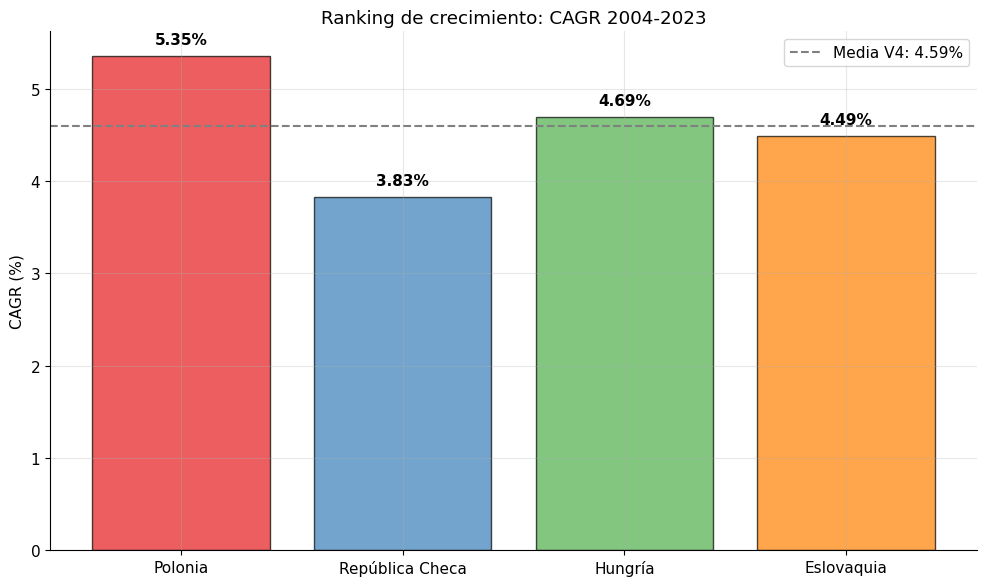

In [6]:
# Gráfica de barras: CAGR
fig, ax = plt.subplots(figsize=(10, 6))

cagr_vals = []
for pais in V4:
    y0 = v4_data[pais].iloc[0]
    yf = v4_data[pais].iloc[-1]
    n = len(v4_data[pais]) - 1
    cagr = (yf / y0) ** (1/n) - 1
    cagr_vals.append(cagr * 100)

colores_bar = [COLORES_V4[p] for p in V4]
bars = ax.bar([NOMBRES_PAIS[p] for p in V4], cagr_vals, 
              color=colores_bar, alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(cagr_vals), color='gray', linestyle='--', 
           label=f'Media V4: {np.mean(cagr_vals):.2f}%')

ax.set_title('Ranking de crecimiento: CAGR 2004-2023')
ax.set_ylabel('CAGR (%)')
ax.legend()

for bar, val in zip(bars, cagr_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f"{val:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
save_figure(fig, '05_ranking_cagr.png')
plt.show()

## 5.2 Nivel Relativo (2004 = 100)

Esta gráfica normaliza el valor de 2004 a 100 para cada país.
Permite comparar el **crecimiento relativo** independientemente del nivel inicial.

Por ejemplo: si Polonia va de 100 a 300, creció 3x.
Si Chequia va de 100 a 150, creció 1.5x.
Polonia creció más en términos relativos, aunque Chequia pueda seguir teniendo
nivel absoluto más alto.

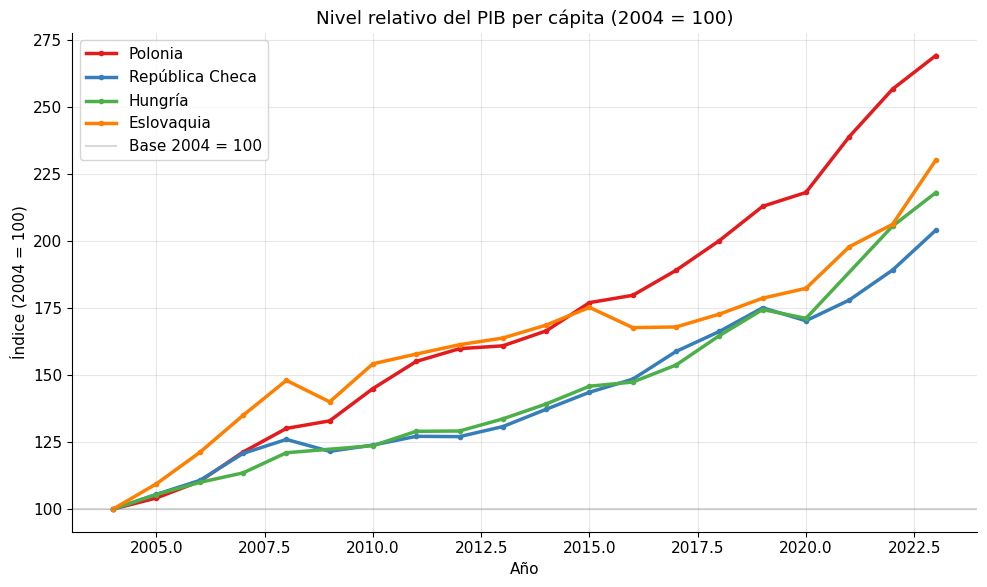

In [7]:
# Calcular nivel relativo (2004 = 100)
fig, ax = plt.subplots(figsize=(10, 6))

for pais in V4:
    base = v4_data[pais].iloc[0]
    nivel_relativo = (v4_data[pais] / base * 100)
    ax.plot(nivel_relativo.index, nivel_relativo.values, 
            color=COLORES_V4[pais], linewidth=2.5, 
            label=NOMBRES_PAIS[pais], marker='o', markersize=3)

ax.axhline(y=100, color='gray', linestyle='-', alpha=0.3, label='Base 2004 = 100')
ax.set_title('Nivel relativo del PIB per cápita (2004 = 100)')
ax.set_xlabel('Año')
ax.set_ylabel('Índice (2004 = 100)')
ax.legend()

plt.tight_layout()
save_figure(fig, '05_nivel_relativo.png')
plt.show()

## 5.3 Proyección Lineal hacia Paridad

**Advertencia importante**: Las proyecciones lineales son simplificaciones.
Asumen que la tendencia histórica se mantiene para siempre, lo cual es poco realista.
Sirven como ejercicio ilustrativo, no como predicción confiable.

La convergencia económica tiene **techo**: ningún país crece al 5% eternamente.
Eventualmente la tasa de crecimiento baja a medida que se acerca al nivel de desarrollo
de los países avanzados.

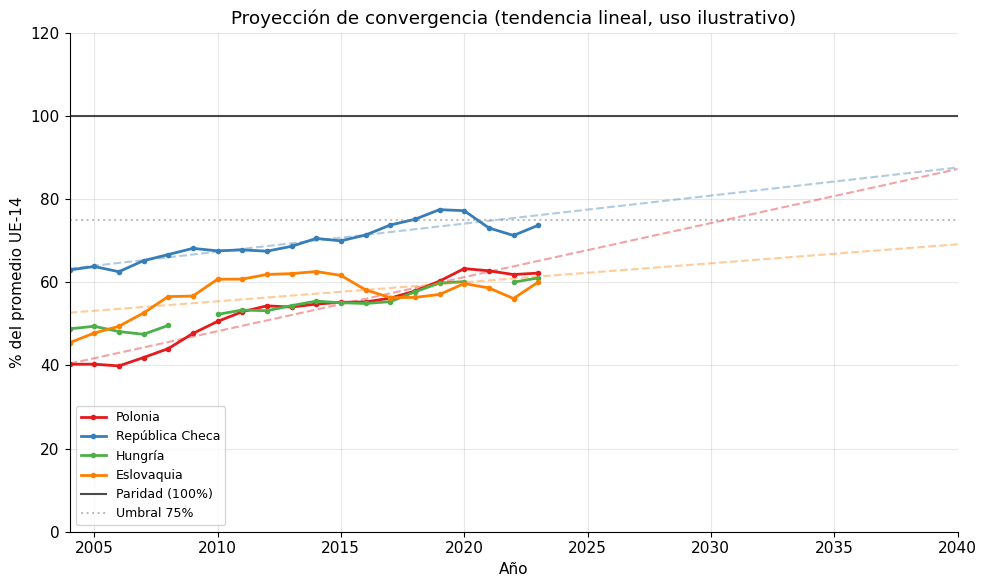

In [13]:
# Proyección lineal del índice de convergencia
fig, ax = plt.subplots(figsize=(10, 6))

años_proj = np.array(range(2004, 2041))

for pais in V4:
    ratios_pais = convergencia[pais].values
    años_pais = convergencia.index.values
    
    # Regresión lineal
    s, inter, _, _, _ = stats.linregress(años_pais, ratios_pais)
    y_proj = s * años_proj + inter
    
    # Dibujar proyección punteada y datos reales
    ax.plot(años_proj, y_proj, "--", color=COLORES_V4[pais], alpha=0.4)
    ax.plot(años_pais, ratios_pais, "o-", color=COLORES_V4[pais], 
            linewidth=2, label=NOMBRES_PAIS[pais], markersize=3)
    
# Calcular año de paridad (si es proyectable)
if s > 0 and inter < 100:
    año_100 = (100 - inter) / s
    if año_100 > 2023 and año_100 < 2100:
        ax.axvline(x=año_100, color=COLORES_V4[pais], linestyle=':', alpha=0.3)
        ax.text(año_100, 50, "{NOMBRES_PAIS[pais][:3]}\\n{año_100:.0f}", 
                ha='center', fontsize=8, color=COLORES_V4[pais])

    ax.axhline(y=100, color='black', linestyle='-', alpha=0.7, label='Paridad (100%)')
    ax.axhline(y=75, color='gray', linestyle=':', alpha=0.5, label='Umbral 75%')
    ax.set_title('Proyección de convergencia (tendencia lineal, uso ilustrativo)')
    ax.set_xlabel('Año')
    ax.set_ylabel('% del promedio UE-14')
    ax.legend(fontsize=9)
    ax.set_xlim(2004, 2040)
    ax.set_ylim(0, 120)

plt.tight_layout()
save_figure(fig, '05_proyeccion_convergencia.png')
plt.show()

## Interpretación de las proyecciones

- **Líneas sólidas**: Datos reales (2004-2023).
- **Líneas punteadas**: Proyección lineal (extrapolación).
- **Línea vertical punteada**: Año estimado de paridad (100%).

**Por qué no son confiables para el largo plazo**:
1. Las economías no crecen linealmente indefinidamente
2. Eventualmente Polonia se acercará a su "techo de desarrollo"
3. Choques económicos, cambios políticos y tecnológicos alteran trayectorias

**Uso correcto**: Identificar si la tendencia actual es suficiente para
alcanzar convergencia en un horizonte razonable (20-30 años).
Si la proyección da 2100+, significa que la tendencia actual NO es suficiente.